# Purpose

This script is an implementation of SHAP (SHapley Additive exPlanations) for the model. 

### Modules

In [8]:
import os
import pandas as pd
import shap
import imp
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

shap.initjs()

### Custom Modules

In [9]:
# import custom modules
this_dir = "/Users/steeleb/Documents/GitHub/TLS_DSS/model_submodule/model_dev/operational_model/"
imp.load_source("universals", os.path.join(this_dir, "universal_functions.py"))
from universals import load_pickle_file, twotemp_labels_features_test

### Load data and models

First, we'll load in the training sets

In [10]:
data_dir = "/Users/steeleb/Documents/GitHub/TLS_DSS/model_submodule/model_dev/operational_model/data/"

all_files = pd.Series(os.listdir(data_dir))
training = all_files[all_files.str.contains('training')]

# these files end up in no particular order, so we need to sort them
training = training.sort_values()

def load_data(file):
    return pd.read_csv(os.path.join(data_dir, file), sep=',')

train1 = load_data(training.values[0])
train2 = load_data(training.values[1])
train3 = load_data(training.values[2])
train4 = load_data(training.values[3])


And we need to process these for ML-ready format. Since we're only using the training data, we can use the get_features_labels_test function

In [11]:
features_1, labels_1 = twotemp_labels_features_test(train1)
features_2, labels_2 = twotemp_labels_features_test(train2)
features_3, labels_3 = twotemp_labels_features_test(train3)
features_4, labels_4 = twotemp_labels_features_test(train4)


And the pickle files for each of the models

In [12]:
model_dir = "/Users/steeleb/Documents/GitHub/TLS_DSS/model_submodule/model_dev/operational_model/dump/three_ten/"

models = [f for f in os.listdir(model_dir) if 'history' not in f]

model_1 = load_pickle_file(models[0], model_dir)
model_2 = load_pickle_file(models[1], model_dir)
model_3 = load_pickle_file(models[2], model_dir)
model_4 = load_pickle_file(models[3], model_dir)


### Model 1

In [13]:
explainer_1 = shap.Explainer(model_1, pd.DataFrame.to_numpy(features_1))
shap_values_1 = explainer_1.shap_values(features_1)

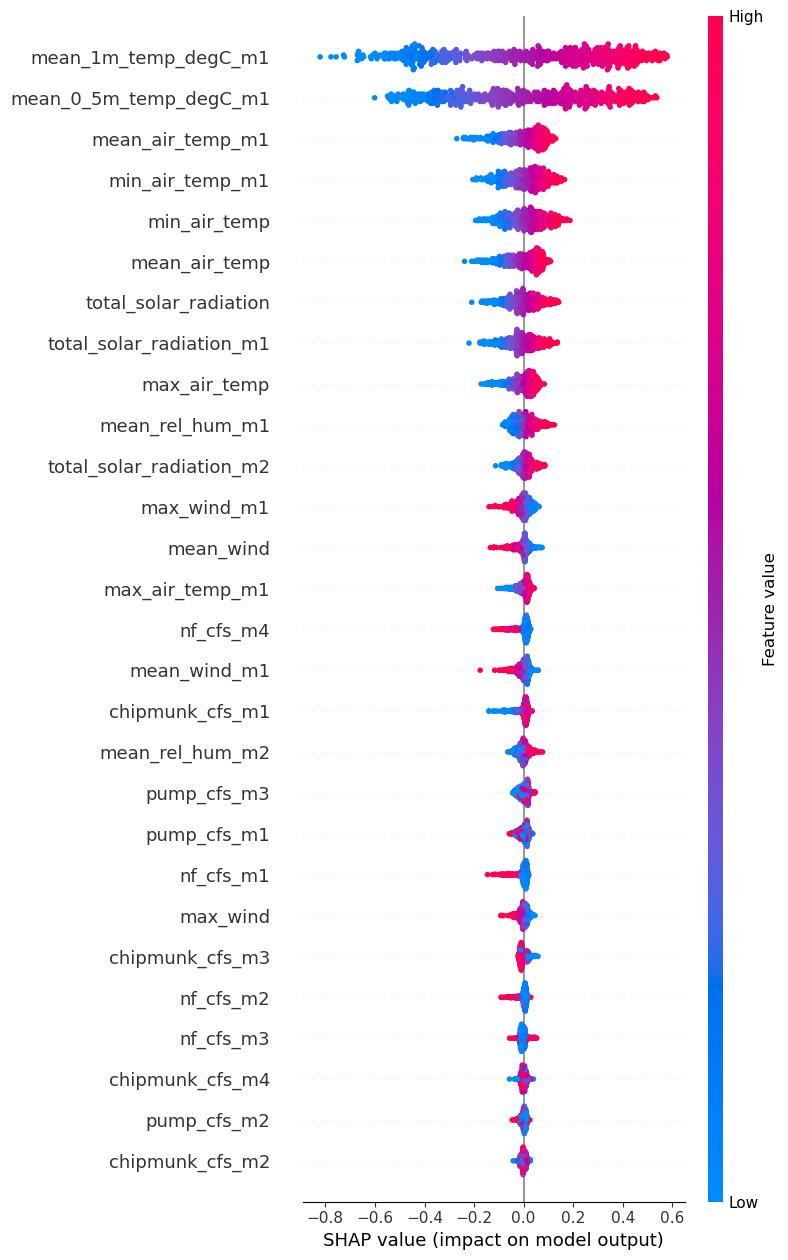

In [14]:
shap_1_1m = (shap.summary_plot(shap_values_1[:, :, 0], 
                            pd.DataFrame.to_numpy(features_1), 
                            max_display=30, 
                            feature_names = features_1.columns, 
                            show=False)
)


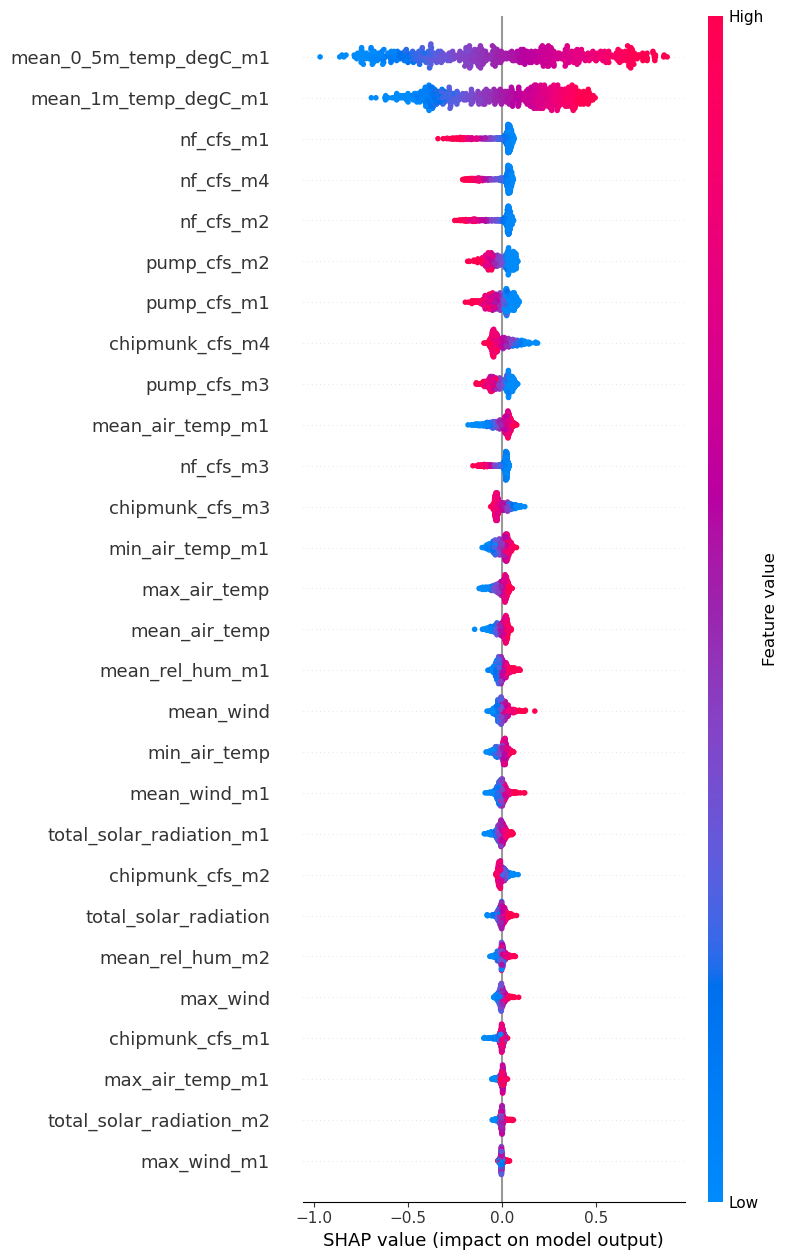

In [15]:

shap_1_int = (shap.summary_plot(shap_values_1[:, :, 1], 
                            pd.DataFrame.to_numpy(features_1), 
                            max_display=30, 
                            feature_names = features_1.columns, 
                            show=False)
)

## Model 2

In [16]:
explainer_2 = shap.Explainer(model_2, pd.DataFrame.to_numpy(features_2))
shap_values_2 = explainer_2.shap_values(features_2)

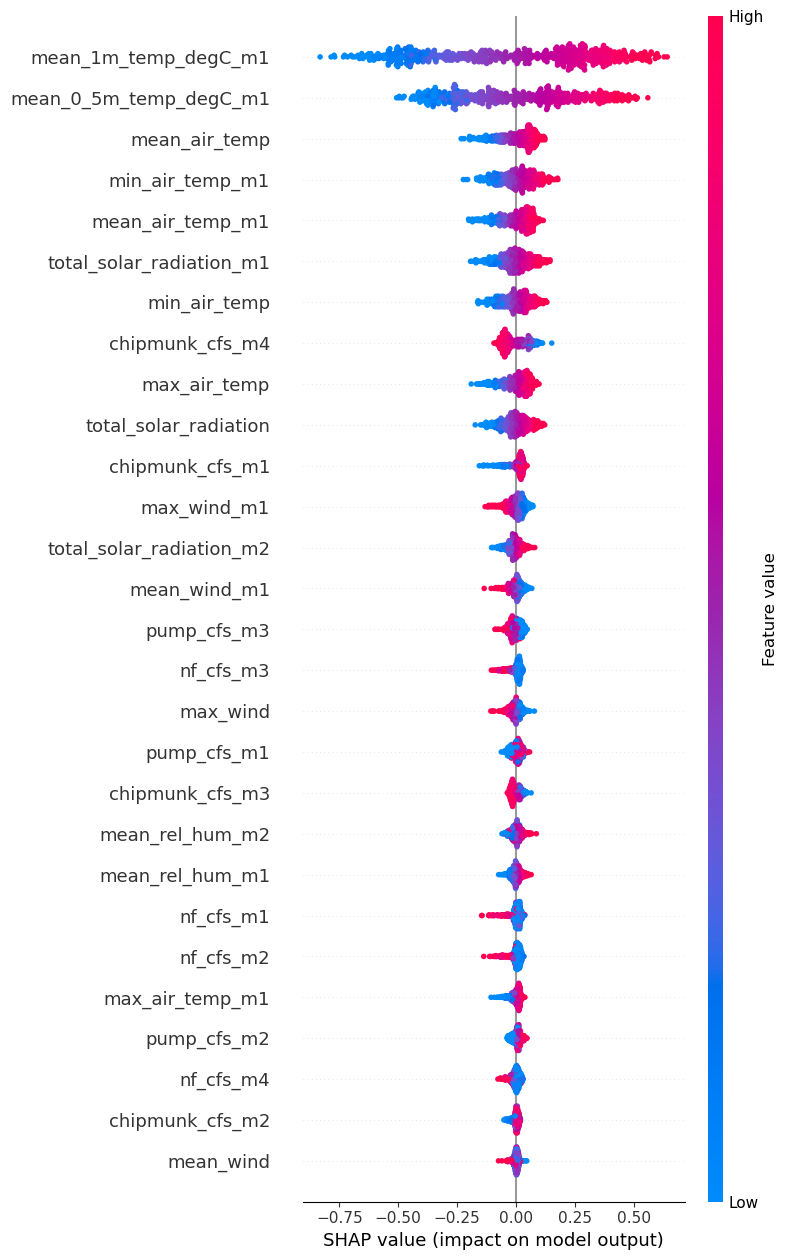

In [17]:
shap_2_1m = (shap.summary_plot(shap_values_2[:, :, 0], 
                            pd.DataFrame.to_numpy(features_2), 
                            max_display=30, 
                            feature_names = features_2.columns, 
                            show=False)
)

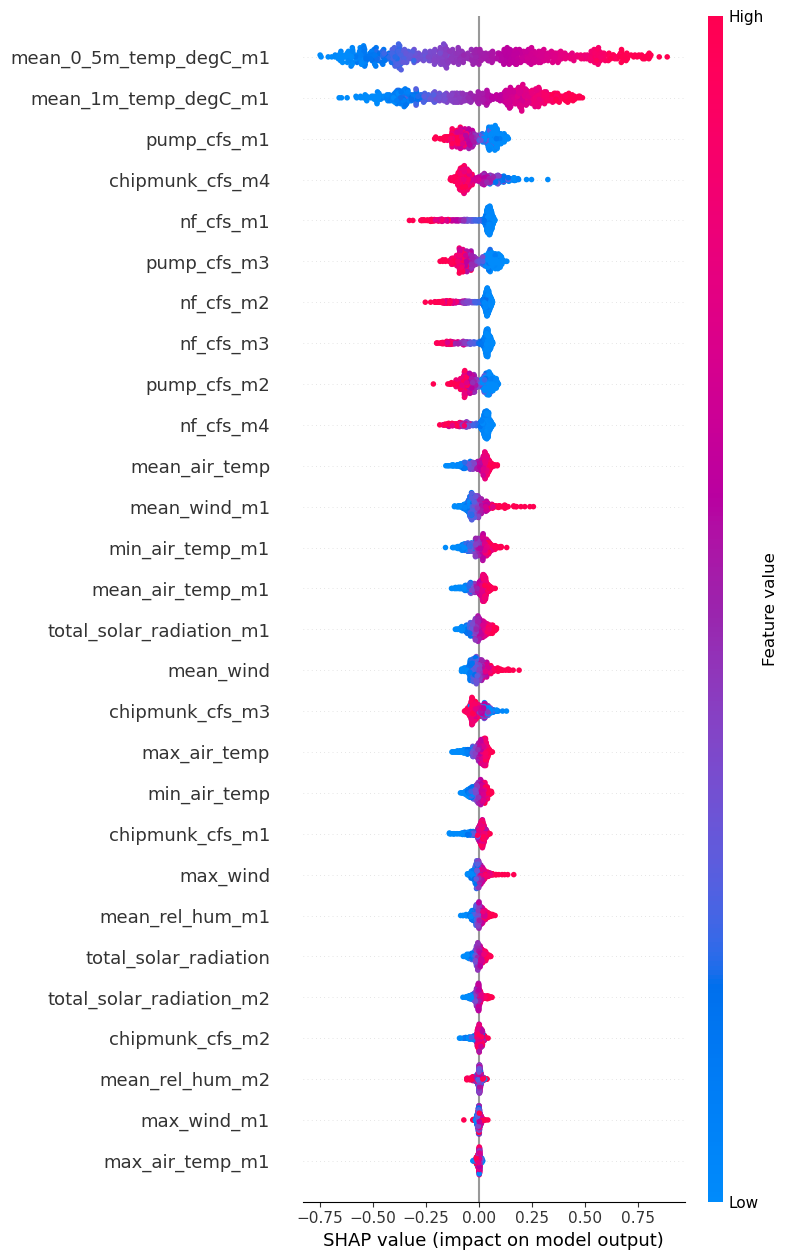

In [18]:
shap_2_int = (shap.summary_plot(shap_values_2[:, :, 1], 
                            pd.DataFrame.to_numpy(features_2), 
                            max_display=30, 
                            feature_names = features_2.columns, 
                            show=False)
)

# Model 3

In [19]:
explainer_3 = shap.Explainer(model_3, pd.DataFrame.to_numpy(features_3))
shap_values_3 = explainer_3.shap_values(features_3)

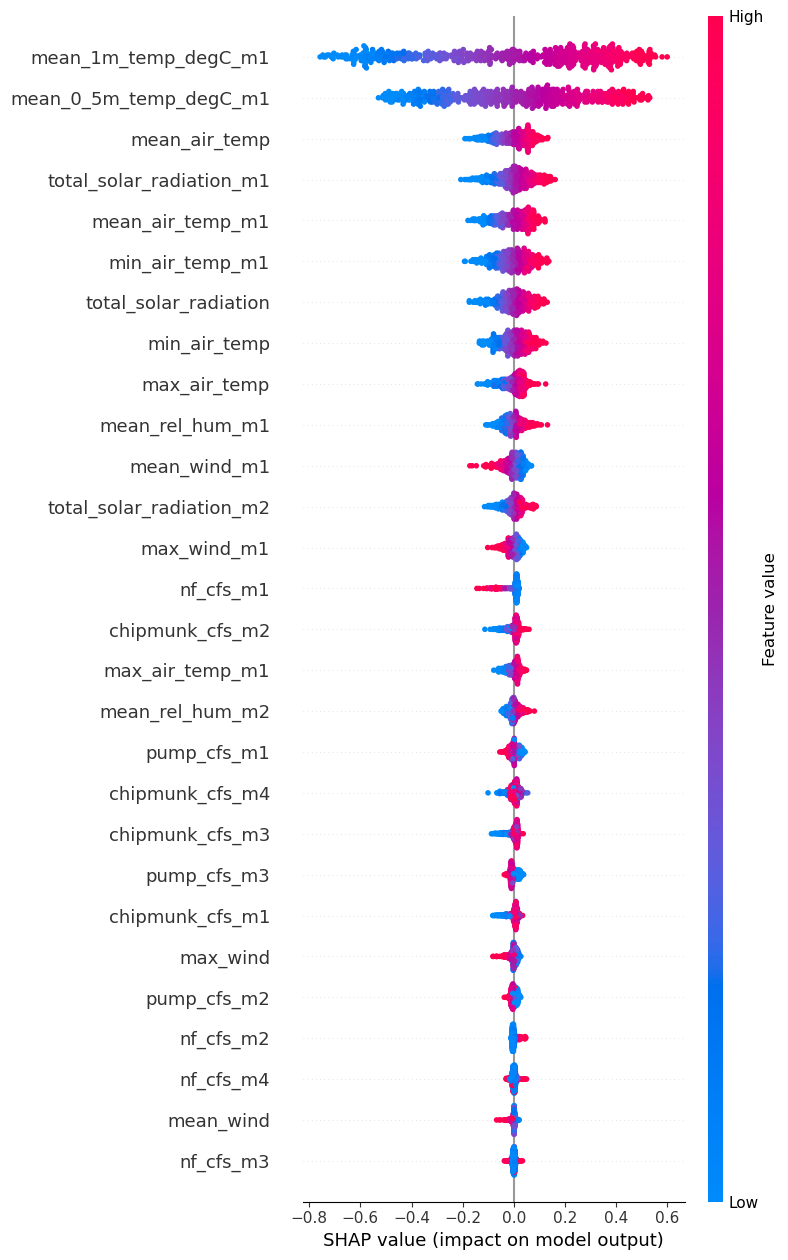

In [20]:
shap_3_1m = (shap.summary_plot(shap_values_3[:, :, 0],
                            pd.DataFrame.to_numpy(features_3), 
                            max_display=30, 
                            feature_names = features_3.columns, 
                            show=False)
)

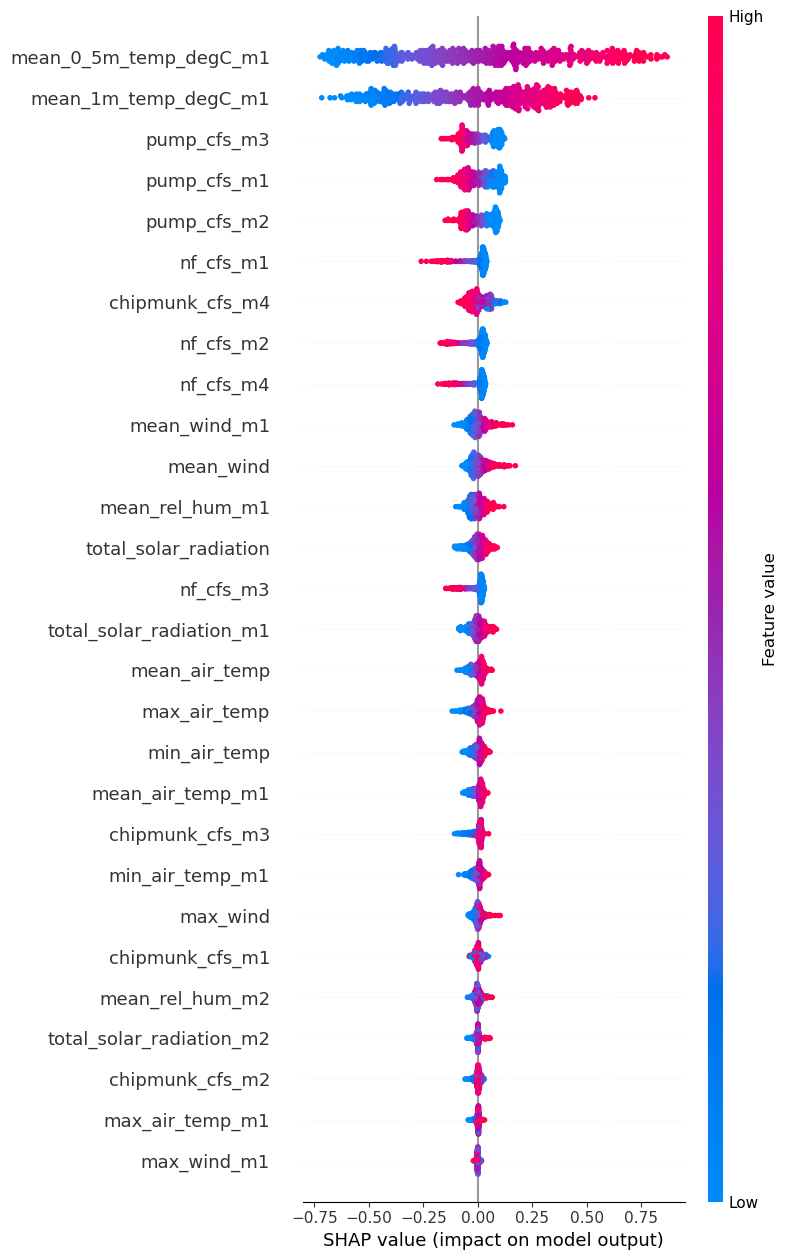

In [21]:
shap_3_int = (shap.summary_plot(shap_values_3[:, :, 1],
                            pd.DataFrame.to_numpy(features_3), 
                            max_display=30, 
                            feature_names = features_3.columns, 
                            show=False)
)

# Model 4

In [22]:
explainer_4 = shap.Explainer(model_4, pd.DataFrame.to_numpy(features_4))
shap_values_4 = explainer_4.shap_values(features_4)

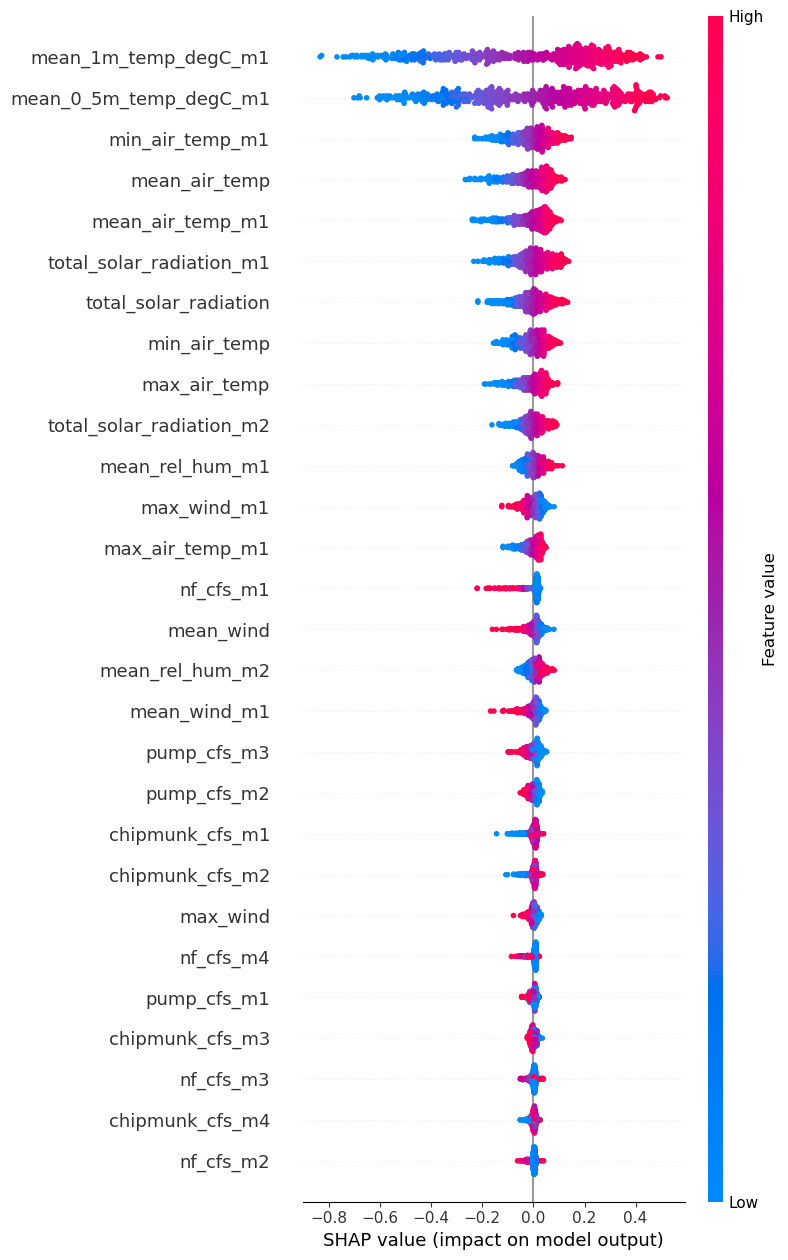

In [23]:
shap_4_1m = (shap.summary_plot(shap_values_4[:, :, 0],
                            pd.DataFrame.to_numpy(features_4), 
                            max_display=30, 
                            feature_names = features_4.columns, 
                            show=False)
)

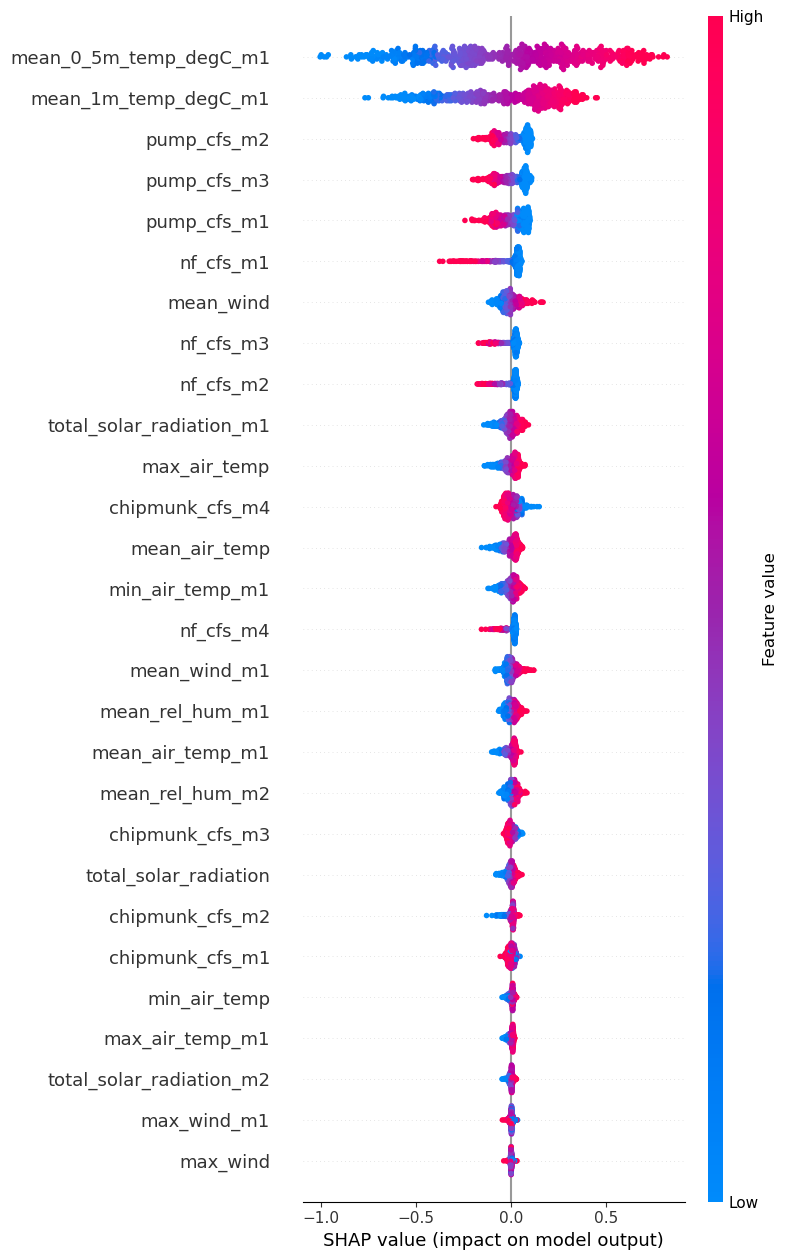

In [24]:
shape_4_int = (shap.summary_plot(shap_values_4[:, :, 1],
                            pd.DataFrame.to_numpy(features_4), 
                            max_display=30, 
                            feature_names = features_4.columns, 
                            show=False)
)

This all looks good to go. We can now see how this all looks in the test set.